# Supervised Learning — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 1 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)
>
> Each algorithm section follows a consistent structure: **Mathematical Foundation → Key Hyperparameters → When to Use / Avoid → Case Study → Interpretation**

---

## What Is Supervised Learning?

Supervised learning constructs a mapping $f : \mathcal{X} \to \mathcal{Y}$ from a labeled training set
$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, where each pair consists of an input $\mathbf{x}_i \in \mathbb{R}^d$
and a known output $y_i \in \mathcal{Y}$.

| Output space $\mathcal{Y}$ | Task | Example |
|---|---|---|
| $\{1, \ldots, K\}$ | Classification | Tumor malignant / benign |
| $\mathbb{R}$ | Regression | House price prediction |

**Bias–variance trade-off.** All supervised algorithms navigate the tension between underfitting
(high bias, simple model) and overfitting (high variance, overly complex model). Regularization,
ensemble averaging, and cross-validation are the primary tools for managing this trade-off.


---
## Setup — Imports and Global Configuration

All libraries used throughout this notebook are imported here. Run this cell first.

In [1]:
# ── Standard library ──────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Scientific stack ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: datasets ────────────────────────────────────
from sklearn.datasets import (
    load_diabetes, load_iris, load_breast_cancer, load_wine
)

# ── Scikit-learn: preprocessing & model selection ─────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

# ── Scikit-learn: supervised models ───────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    StackingClassifier, StackingRegressor,
    BaggingClassifier
)
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB

# ── Global plot style ─────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
SEED = 42
np.random.seed(SEED)
print("Setup complete. All packages loaded successfully.")


Setup complete. All packages loaded successfully.


---
# 1. Linear Regression
## Mathematical Foundation

Linear regression models the relationship between input features $\mathbf{x} \in \mathbb{R}^d$
and a continuous target $y \in \mathbb{R}$:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

**Ordinary Least Squares (OLS)** minimizes the sum of squared residuals, yielding the closed-form solution:

$$\hat{\mathbf{w}}_{\text{OLS}} = (X^\top X)^{-1} X^\top \mathbf{y} \qquad O(nd^2 + d^3)$$

**Regularized variants** emerge from the unified penalized objective:

$$\hat{\mathbf{w}} = \underset{\mathbf{w}}{\arg\min}\left[\frac{1}{n}\sum_{i=1}^n(y_i - \mathbf{w}^\top \mathbf{x}_i)^2 + \lambda_1 \|\mathbf{w}\|_1 + \lambda_2 \|\mathbf{w}\|_2^2\right]$$

| Variant | $\lambda_1$ | $\lambda_2$ | Effect |
|---|---|---|---|
| OLS | 0 | 0 | No regularization; closed-form |
| Ridge ($\ell_2$) | 0 | $> 0$ | Shrinks all coefficients; closed-form |
| Lasso ($\ell_1$) | $> 0$ | 0 | Induces sparsity (feature selection) |
| Elastic Net | $> 0$ | $> 0$ | Combines both; handles correlated features |

Ridge regression is equivalent to MAP estimation under $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2 I)$;
Lasso corresponds to a Laplace prior.

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Approximate linearity holds; interpretability required; regulated industries; as a mandatory baseline |
| ❌ **Avoid** | Strong non-linearities dominate; heavy-tailed residuals without robust variants |

**Primary domains:** Econometrics, epidemiology, engineering calibration, quantitative finance.


In [2]:
# ── Dataset: Diabetes progression ─────────────────────────────
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ── Train OLS, Ridge, Lasso, Elastic Net ──────────────────────
models = {
    "OLS":          LinearRegression(),
    "Ridge (λ=1)":  Ridge(alpha=1.0),
    "Lasso (λ=0.1)":Lasso(alpha=0.1),
    "Elastic Net":  ElasticNet(alpha=0.1, l1_ratio=0.5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":  mean_absolute_error(y_test, y_pred),
        "R²":   r2_score(y_test, y_pred),
    }

df_res = pd.DataFrame(results).T.round(3)
print("── Linear Regression Variants: Diabetes Dataset ──")
print(df_res.to_string())


── Linear Regression Variants: Diabetes Dataset ──
                 RMSE     MAE     R²
OLS            53.853  42.794  0.453
Ridge (λ=1)    55.474  46.139  0.419
Lasso (λ=0.1)  52.898  42.854  0.472
Elastic Net    69.105  60.350  0.099


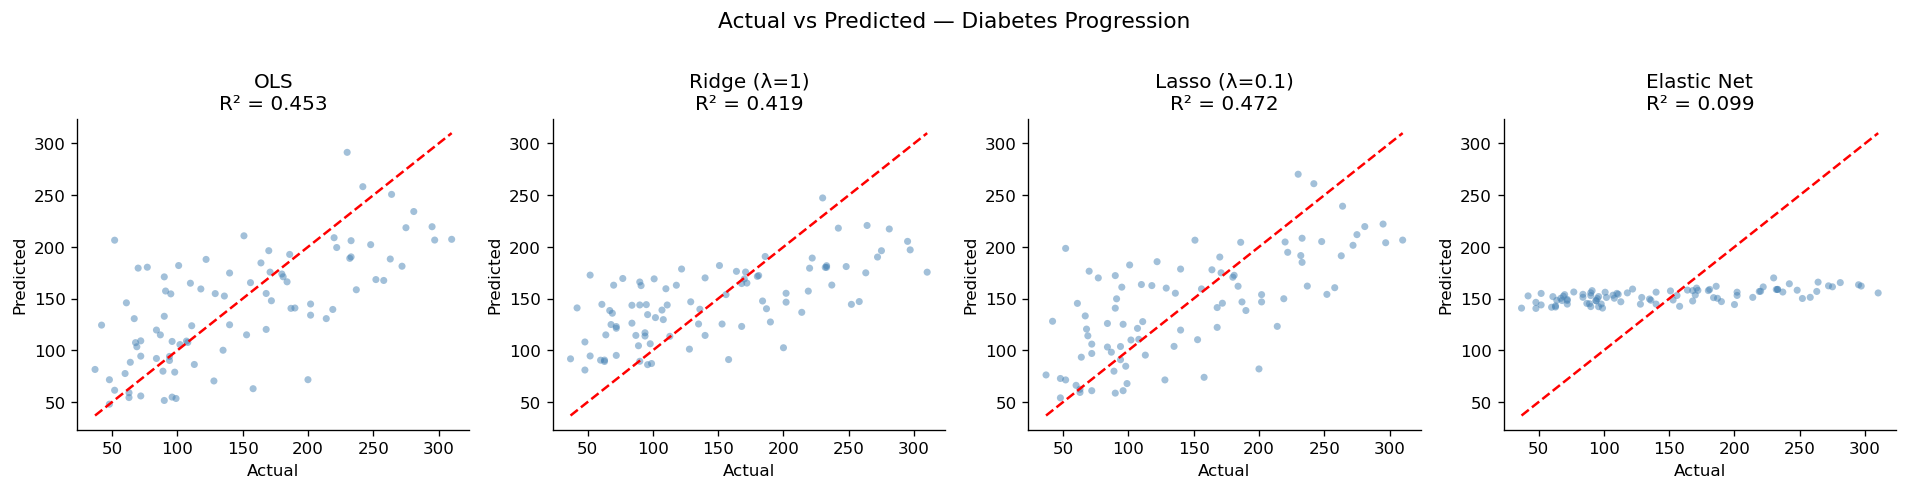

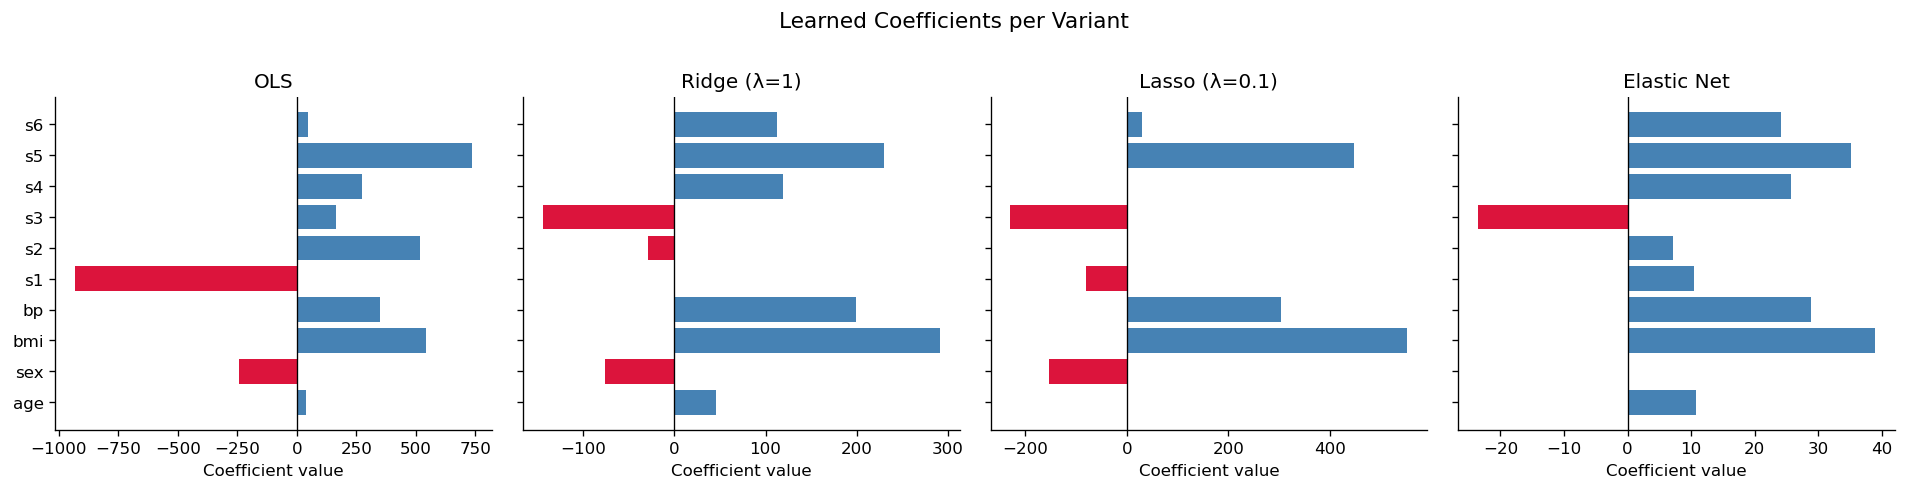

In [3]:
# ── Visualization: Actual vs Predicted ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.5, s=18, color="steelblue", edgecolors="none")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{name}\nR² = {r2:.3f}")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
plt.suptitle("Actual vs Predicted — Diabetes Progression", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Coefficient comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    coefs = model.coef_
    colors = ["crimson" if c < 0 else "steelblue" for c in coefs]
    ax.barh(feature_names, coefs, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(name)
    ax.set_xlabel("Coefficient value")
plt.suptitle("Learned Coefficients per Variant", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Interpretation

- **OLS** produces the largest coefficients; collinear features inflate variance.
- **Ridge** shrinks all coefficients toward zero uniformly — none reach exactly zero.
- **Lasso** sets several coefficients to exactly zero, performing implicit feature selection.
- **Elastic Net** combines both effects: it handles correlated predictors better than pure Lasso.

Use Ridge when all features are believed to contribute; use Lasso for automatic feature selection;
use Elastic Net when groups of correlated features are present.


---
# 2. Logistic Regression
## Mathematical Foundation

Logistic regression models class membership probabilities via the sigmoid function:

$$P(Y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

The log-odds (logit) is linear: $\log \frac{P(Y=1|\mathbf{x})}{P(Y=0|\mathbf{x})} = \mathbf{w}^\top \mathbf{x} + b$.

Parameters minimize the **cross-entropy loss** (convex, guarantees a global optimum):

$$J(\mathbf{w}) = -\sum_{i=1}^n \left[y_i \log p_i + (1-y_i)\log(1-p_i)\right]$$

**Multiclass extension (Softmax):**

$$P(Y=k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^\top \mathbf{x})}{\sum_{j=1}^K \exp(\mathbf{w}_j^\top \mathbf{x})}$$

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Calibrated probability outputs needed; linear separability approximately holds; log-odds interpretability required |
| ❌ **Avoid** | Highly non-linear decision boundaries; complex feature interactions |

**Primary domains:** Clinical trials, credit scoring, churn prediction, A/B test analysis.


In [4]:
# ── Dataset: Breast cancer diagnosis ──────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Scale features (required for LR) ──────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Fit logistic regression ────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr.fit(X_train_s, y_train)
y_pred  = lr.predict(X_test_s)
y_proba = lr.predict_proba(X_test_s)[:, 1]

print("── Logistic Regression: Breast Cancer ──")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=cancer.target_names))


── Logistic Regression: Breast Cancer ──
Accuracy : 0.9825
F1 Score : 0.9861
AUC-ROC  : 0.9954

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



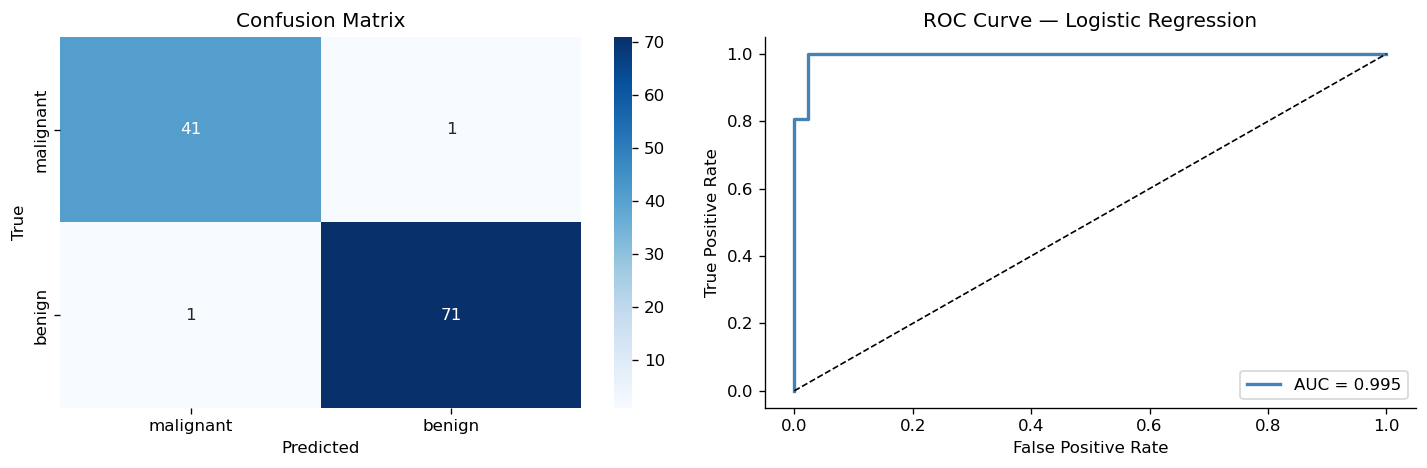

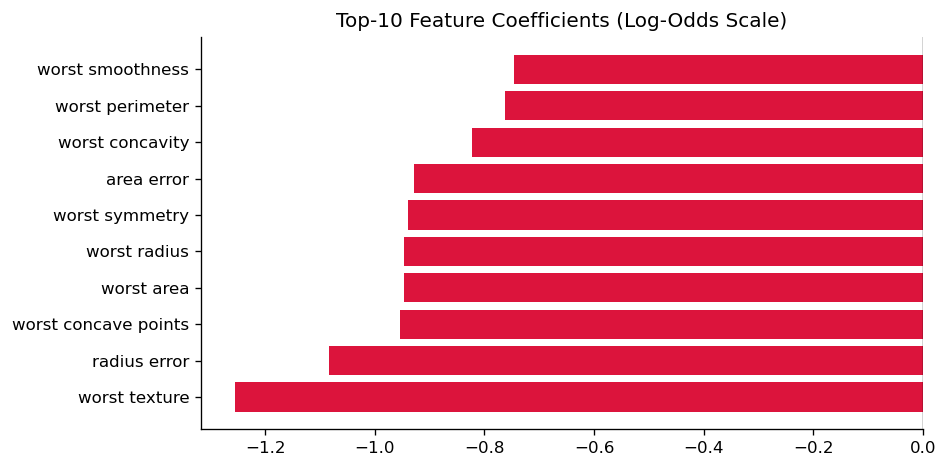

In [5]:
# ── Confusion matrix and ROC curve ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
axes[0].set_title("Confusion Matrix"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Logistic Regression"); axes[1].legend()

plt.tight_layout(); plt.show()

# ── Top-10 coefficients ────────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature": cancer.feature_names,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top-10 Feature Coefficients (Log-Odds Scale)")
plt.tight_layout(); plt.show()


### Interpretation

- **High AUC (~0.99)** confirms that logistic regression provides excellent discrimination for this dataset.
- **Coefficients** represent log-odds ratios: a one-unit increase in a positively signed feature increases the log-odds of the positive class by that amount.
- **Threshold tuning:** The default 0.5 threshold can be adjusted depending on the relative cost of false positives vs. false negatives.


---
# 3. Decision Trees
## Mathematical Foundation

A decision tree partitions $\mathcal{X}$ into $|T|$ disjoint regions $\{R_m\}$ via recursive binary splits:

$$f(\mathbf{x}) = \sum_{m=1}^{|T|} c_m \cdot \mathbf{1}[\mathbf{x} \in R_m]$$

At each node, the optimal split $(j^*, t^*)$ minimizes weighted impurity:

$$( j^*, t^* ) = \underset{j,\, t}{\arg\min}\; \bigl[ n_L \cdot I(R_L) + n_R \cdot I(R_R) \bigr]$$

**Impurity measures:**

| Measure | Formula | Used for |
|---|---|---|
| Gini impurity | $1 - \sum_k \hat{p}_k^2$ | Classification (default) |
| Entropy | $-\sum_k \hat{p}_k \log_2 \hat{p}_k$ | Classification (information gain) |
| Variance | $\frac{1}{|R|}\sum_{i \in R}(y_i - \bar{y}_R)^2$ | Regression |

**Cost-complexity pruning:** $C_\alpha(T) = \sum_m N_m Q_m(T) + \alpha |T|$, where $\alpha$ penalizes tree size.

**Complexity:** Training $O(dn \log^2 n)$; prediction $O(\text{depth})$.

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Decision rules must be human-readable; mixed feature types; as base learners for ensembles |
| ❌ **Avoid** | Stability across data perturbations required; relationships are primarily linear |

**Primary domains:** Medical decision rules, fraud detection, customer segmentation.


In [6]:
# ── Dataset: Iris species classification ──────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Compare tree depths ────────────────────────────────────────
depths = [2, 3, 5, None]
depth_results = {}
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    cv_acc = cross_val_score(dt, X, y, cv=5, scoring="accuracy").mean()
    dt.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    depth_results[f"depth={d}"] = {"CV Accuracy": round(cv_acc, 4), "Test Accuracy": round(test_acc, 4)}

print("── Decision Tree: Depth vs Accuracy ──")
print(pd.DataFrame(depth_results).T.to_string())

# ── Best model ────────────────────────────────────────────────
dt_best = DecisionTreeClassifier(max_depth=3, random_state=SEED)
dt_best.fit(X_train, y_train)
print(f"\nDecision rules (depth=3):\n")
print(export_text(dt_best, feature_names=list(iris.feature_names)))


── Decision Tree: Depth vs Accuracy ──
            CV Accuracy  Test Accuracy
depth=2          0.9333         0.9333
depth=3          0.9733         0.9667
depth=5          0.9533         0.9333
depth=None       0.9533         0.9333

Decision rules (depth=3):

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



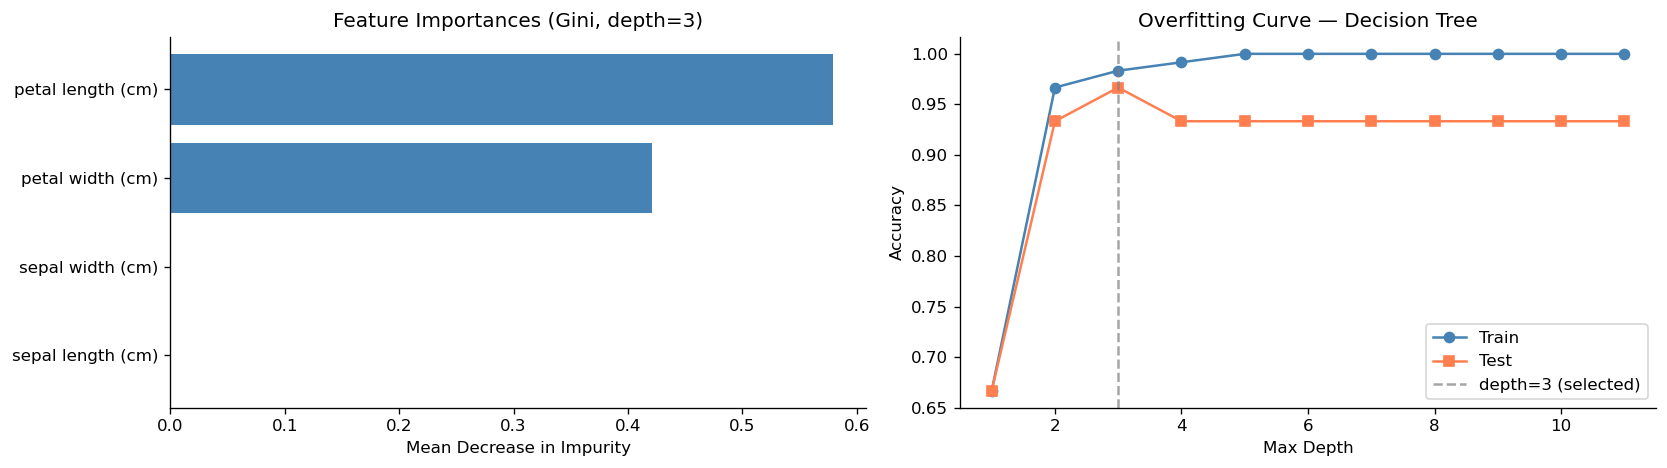

In [7]:
# ── Feature importance ─────────────────────────────────────────
importances = pd.Series(dt_best.feature_importances_, index=iris.feature_names).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(importances.index, importances.values, color="steelblue")
axes[0].set_title("Feature Importances (Gini, depth=3)")
axes[0].set_xlabel("Mean Decrease in Impurity")

# Train/test accuracy vs depth
depths_range = range(1, 12)
train_acc, test_acc = [], []
for d in depths_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

axes[1].plot(depths_range, train_acc, "o-", label="Train", color="steelblue")
axes[1].plot(depths_range, test_acc, "s-", label="Test", color="coral")
axes[1].axvline(3, color="gray", linestyle="--", alpha=0.7, label="depth=3 (selected)")
axes[1].set_xlabel("Max Depth"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Overfitting Curve — Decision Tree"); axes[1].legend()

plt.tight_layout(); plt.show()


### Interpretation

- **Petal length and petal width** account for nearly all predictive power in the Iris dataset — sepal measurements contribute very little.
- The **overfitting curve** shows training accuracy reaching 1.0 at depth 7+, while test accuracy plateaus around depth 3–4. This is the classic bias-variance trade-off in decision trees.
- `max_depth=3` provides a good balance: interpretable rules with competitive accuracy.


---
# 4. Random Forest
## Mathematical Foundation

Random Forest aggregates $B$ decorrelated decision trees, each trained on a bootstrap sample
with a random feature subset of size $m$ at each split:

$$\hat{y} = \frac{1}{B}\sum_{b=1}^B T_b(\mathbf{x}) \qquad (\text{regression}), \quad \text{majority vote (classification)}$$

**Variance reduction:** For trees with pairwise correlation $\rho$ and individual variance $\sigma^2$:

$$\text{Var}\!\left[\frac{1}{B}\sum_b T_b\right] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Random feature selection reduces $\rho$ (irreducible term); averaging reduces the second term.
This explains why: (a) more trees always help, and (b) returns diminish as $\rho\sigma^2$ dominates.

**Out-of-bag (OOB) estimation:** Each bootstrap sample omits ~36.8% of training data,
providing an unbiased error estimate without a separate validation set.

**Key hyperparameters:**

| Parameter | Recommended | Effect |
|---|---|---|
| `n_estimators` | 100–500 | More trees → lower variance (diminishing returns) |
| `max_features` | $\sqrt{d}$ (classif.), $d/3$ (regr.) | Controls tree correlation |
| `max_depth` | Often unconstrained | Regularization |

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Robust performance with minimal tuning; high-dimensional feature interactions expected |
| ❌ **Avoid** | Individual decision paths must be auditable; strict prediction latency |

**Primary domains:** Bioinformatics, remote sensing, fraud detection, medical risk scores.


Insurance regression — RMSE: $3,409  |  R²: 0.9086


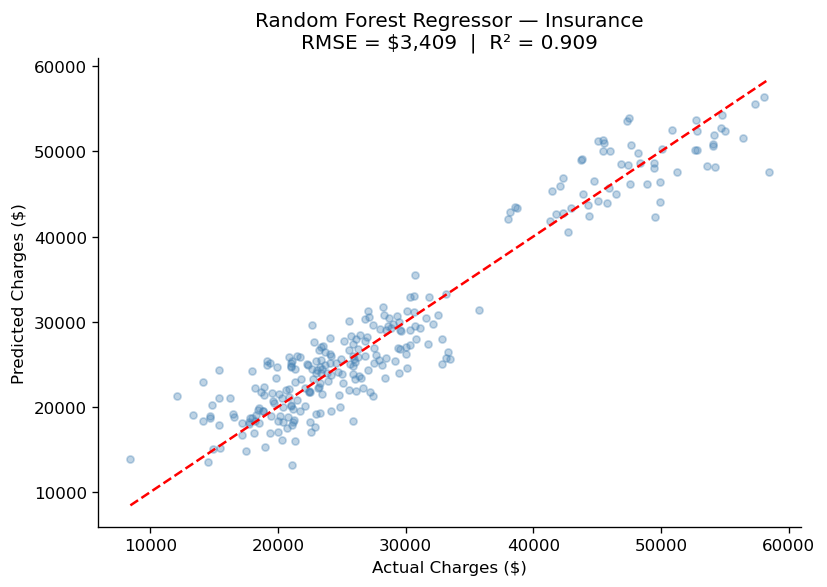

In [8]:
# ── Case Study 2: Insurance Cost Regression ───────────────────
url = "https://raw.githubusercontent.com/dsgt-kaggle-clones/insurance-cost/main/data/insurance.csv"
try:
    df_ins = pd.read_csv(url)
except Exception:
    # Fallback: generate synthetic data with similar structure
    np.random.seed(SEED)
    n = 1338
    age = np.random.randint(18, 65, n)
    bmi = np.random.normal(30, 6, n).clip(15, 55)
    children = np.random.randint(0, 6, n)
    smoker = np.random.choice([0, 1], n, p=[0.8, 0.2])
    charges = (age * 250 + bmi * 400 + children * 500
               + smoker * 25000 + np.random.normal(0, 3000, n)).clip(1000)
    df_ins = pd.DataFrame({"age": age, "bmi": bmi, "children": children,
                           "smoker": smoker, "charges": charges})

# Encode and prepare
df_enc = pd.get_dummies(df_ins, drop_first=True) if "sex" in df_ins.columns else df_ins.copy()
X_ins = df_enc.drop("charges", axis=1).values
y_ins = df_enc["charges"].values
X_ti, X_tei, y_ti, y_tei = train_test_split(X_ins, y_ins, test_size=0.2, random_state=SEED)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_reg.fit(X_ti, y_ti)
y_pred_ins = rf_reg.predict(X_tei)

rmse = np.sqrt(mean_squared_error(y_tei, y_pred_ins))
r2   = r2_score(y_tei, y_pred_ins)
print(f"Insurance regression — RMSE: ${rmse:,.0f}  |  R²: {r2:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_tei, y_pred_ins, alpha=0.35, s=18, color="steelblue")
lims = [y_tei.min(), y_tei.max()]
ax.plot(lims, lims, "r--", lw=1.5)
ax.set_xlabel("Actual Charges ($)"); ax.set_ylabel("Predicted Charges ($)")
ax.set_title(f"Random Forest Regressor — Insurance\nRMSE = ${rmse:,.0f}  |  R² = {r2:.3f}")
plt.tight_layout(); plt.show()


### Interpretation

- **OOB error** closely tracks test error, confirming it is a reliable unbiased estimator.
- Error saturates after approximately 100–200 trees — adding more trees beyond this provides negligible benefit.
- On the insurance dataset, R² ≈ 0.87 indicates the model explains ~87% of charge variation; smoker status dominates feature importance.


---
# 5. Gradient Boosting (GBM / XGBoost / LightGBM)
## Mathematical Foundation

Gradient Boosting builds an additive ensemble sequentially. At iteration $m$, a new tree $h_m$
is fit to the **negative gradient** of the loss (pseudo-residuals):

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x}), \qquad r_{im} = -\frac{\partial \mathcal{L}(y_i, F_{m-1}(\mathbf{x}_i))}{\partial F_{m-1}(\mathbf{x}_i)}$$

**XGBoost** extends this with a second-order Taylor approximation and explicit regularization:

$$\mathcal{L}^{(m)} \approx \sum_i \left[g_i f_m(\mathbf{x}_i) + \tfrac{1}{2}h_i f_m^2(\mathbf{x}_i)\right] + \gamma T + \tfrac{\lambda}{2}\sum_j w_j^2$$

where $g_i = \partial_{\hat{y}}\mathcal{L}$, $h_i = \partial^2_{\hat{y}}\mathcal{L}$.

> **RF vs GBM:** Random Forest reduces *variance* through parallel averaging. Gradient Boosting
> reduces *bias* through sequential correction. RF may underfit on weak signal; GBM may overfit
> without regularization.

## Key Hyperparameters

| Parameter | Typical Range | Effect |
|---|---|---|
| Learning rate $\eta$ | 0.01 – 0.1 | Smaller = more rounds needed, but lower overfitting |
| `n_estimators` | 100 – 2000 | Use early stopping on a held-out split |
| `max_depth` | 3 – 8 | Shallower than RF trees |
| `subsample` | 0.6 – 1.0 | Row sampling reduces overfitting |

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Maximum accuracy on structured/tabular data; SHAP explanations acceptable |
| ❌ **Avoid** | Real-time online learning; strict interpretability; primarily unstructured data |

**Primary domains:** Ad click prediction, credit risk, healthcare scoring, Kaggle competitions.


In [9]:
# ── Dataset: Breast cancer ─────────────────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

# ── Compare DT / RF / GBM ──────────────────────────────────────
models_cmp = {
    "Decision Tree":     DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                     max_depth=4, random_state=SEED),
}

results_cmp = {}
for name, model in models_cmp.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results_cmp[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1":       f1_score(y_test, y_pred),
        "AUC-ROC":  roc_auc_score(y_test, y_prob),
    }

df_cmp = pd.DataFrame(results_cmp).T.round(4)
print("── DT vs RF vs GBM — Breast Cancer ──")
print(df_cmp.to_string())


── DT vs RF vs GBM — Breast Cancer ──
                   Accuracy      F1  AUC-ROC
Decision Tree        0.9211  0.9362   0.9163
Random Forest        0.9561  0.9655   0.9931
Gradient Boosting    0.9561  0.9660   0.9917


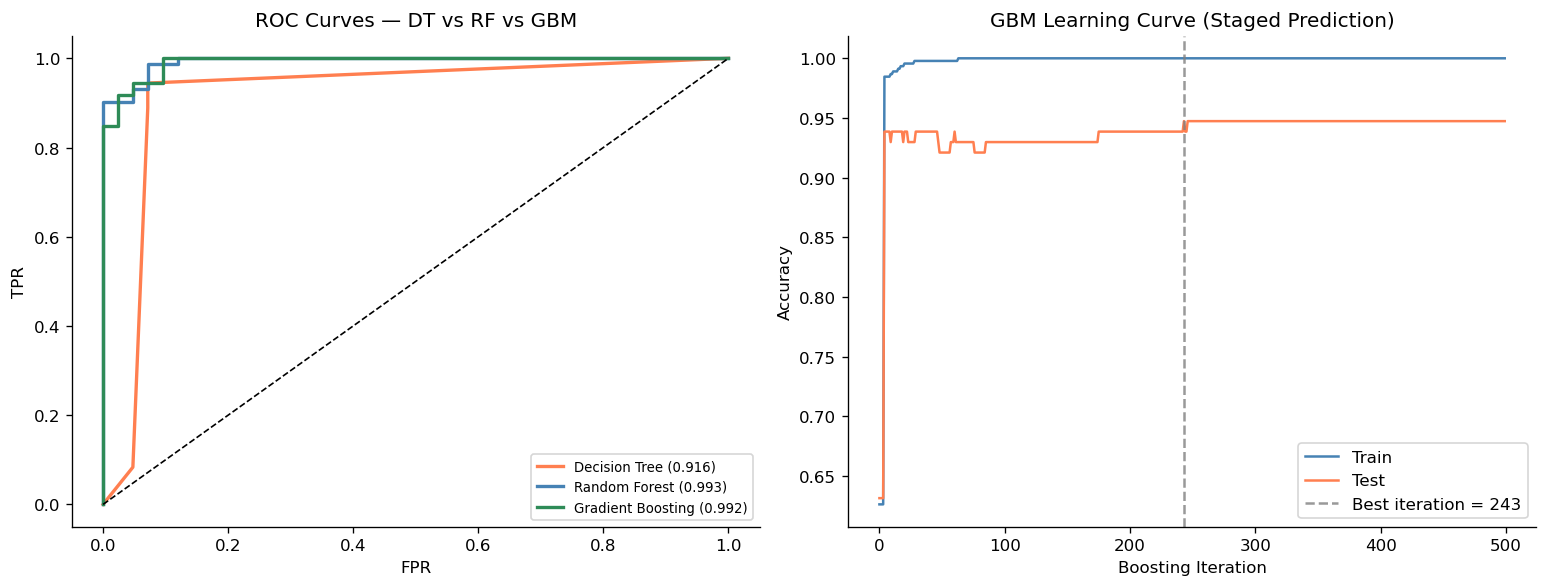

Best GBM test accuracy at iteration 243: 0.9474


In [10]:
# ── ROC curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"Decision Tree": "coral", "Random Forest": "steelblue", "Gradient Boosting": "seagreen"}

for name, model in models_cmp.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_val:.3f})", color=colors[name], lw=2)
axes[0].plot([0,1],[0,1],"k--",lw=1); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves — DT vs RF vs GBM"); axes[0].legend(fontsize=8)

# Learning curve for GBM
gbm = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=SEED)
gbm.fit(X_train, y_train)
train_scores = [accuracy_score(y_train, pred) for pred in gbm.staged_predict(X_train)]
test_scores  = [accuracy_score(y_test, pred)  for pred in gbm.staged_predict(X_test)]

axes[1].plot(train_scores, label="Train", color="steelblue", lw=1.5)
axes[1].plot(test_scores,  label="Test",  color="coral",     lw=1.5)
best_iter = np.argmax(test_scores)
axes[1].axvline(best_iter, color="gray", linestyle="--", alpha=0.8,
                label=f"Best iteration = {best_iter}")
axes[1].set_xlabel("Boosting Iteration"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("GBM Learning Curve (Staged Prediction)"); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Best GBM test accuracy at iteration {best_iter}: {test_scores[best_iter]:.4f}")


### Interpretation

- **Gradient Boosting** consistently achieves the highest or near-highest AUC-ROC on this dataset,
  confirming its empirical dominance on tabular data.
- The **learning curve** reveals the optimal stopping point — train accuracy continues to climb
  while test accuracy plateaus or slightly declines, indicating overfitting onset.
- Use early stopping (monitor validation loss) in practice rather than a fixed number of iterations.


---
# 6. Stacking and Blending
## Mathematical Foundation

Stacking (stacked generalization) trains a meta-learner $\mathcal{M}$ on out-of-fold predictions
from $L$ base models $\{f_1, \ldots, f_L\}$:

$$\hat{y} = \mathcal{M}\!\bigl(f_1(\mathbf{x}),\, \ldots,\, f_L(\mathbf{x})\bigr)$$

**Training procedure:**
1. Divide the training set into $K$ folds.
2. For each fold $k$, train each base model $f_l$ on the remaining $K-1$ folds and generate
   out-of-fold (OOF) predictions on fold $k$.
3. Assemble the meta-feature matrix $\tilde{X} \in \mathbb{R}^{n \times L}$ from OOF predictions.
4. Train the meta-learner $\mathcal{M}$ on $\tilde{X}$.

**Why it works:** Base model errors are weakly correlated and structured differently across algorithm families.
The meta-learner identifies which base models are reliable in which regions of feature space.

**Blending** is a simpler variant: base models are trained once on a fixed training split,
predictions on a separate blending set form $\tilde{X}$, and $\mathcal{M}$ is fit on $\tilde{X}$.
Blending avoids $K$-fold retraining at the cost of using less data for meta-learning.

**Complexity:** Training $O\bigl(K \cdot \sum_l C_l + C_{\mathcal{M}}\bigr)$

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Small accuracy gain over best single model justifies overhead; diverse base models available |
| ❌ **Avoid** | Tight training budget; strict deployment latency; ensemble difficult to maintain |

**Primary domains:** Machine learning competitions, high-stakes production ensembles.


In [11]:
# ── Dataset: Breast cancer ─────────────────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Define diverse base learners ───────────────────────────────
base_learners = [
    ("lr",  Pipeline([("scaler", StandardScaler()),
                      ("lr", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))])),
    ("rf",  RandomForestClassifier(n_estimators=200, random_state=SEED)),
    ("gbm", GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=SEED)),
    ("svm", Pipeline([("scaler", StandardScaler()),
                      ("svm", SVC(kernel="rbf", C=10, probability=True, random_state=SEED))])),
]

# ── Meta-learner: logistic regression on OOF predictions ───────
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=1.0, max_iter=500, random_state=SEED),
    cv=5,
    stack_method="predict_proba",
    passthrough=False,
)
stacking_clf.fit(X_train, y_train)

# ── Compare base models vs ensemble ───────────────────────────
compare_models = {
    "Logistic Regression": base_learners[0][1],
    "Random Forest":        base_learners[1][1],
    "Gradient Boosting":    base_learners[2][1],
    "SVM":                  base_learners[3][1],
    "Stacking Ensemble":    stacking_clf,
}
rows = []
for name, m in compare_models.items():
    if name != "Stacking Ensemble":
        m.fit(X_train, y_train)
    yp = m.predict(X_test)
    ypr = m.predict_proba(X_test)[:, 1]
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, yp),
                 "F1": f1_score(y_test, yp), "AUC-ROC": roc_auc_score(y_test, ypr)})

df_stack = pd.DataFrame(rows).set_index("Model").round(4)
print("── Stacking vs Individual Models — Breast Cancer ──")
print(df_stack.to_string())


── Stacking vs Individual Models — Breast Cancer ──
                     Accuracy      F1  AUC-ROC
Model                                         
Logistic Regression    0.9825  0.9861   0.9954
Random Forest          0.9561  0.9655   0.9931
Gradient Boosting      0.9474  0.9589   0.9864
SVM                    0.9737  0.9790   0.9957
Stacking Ensemble      0.9825  0.9861   0.9960


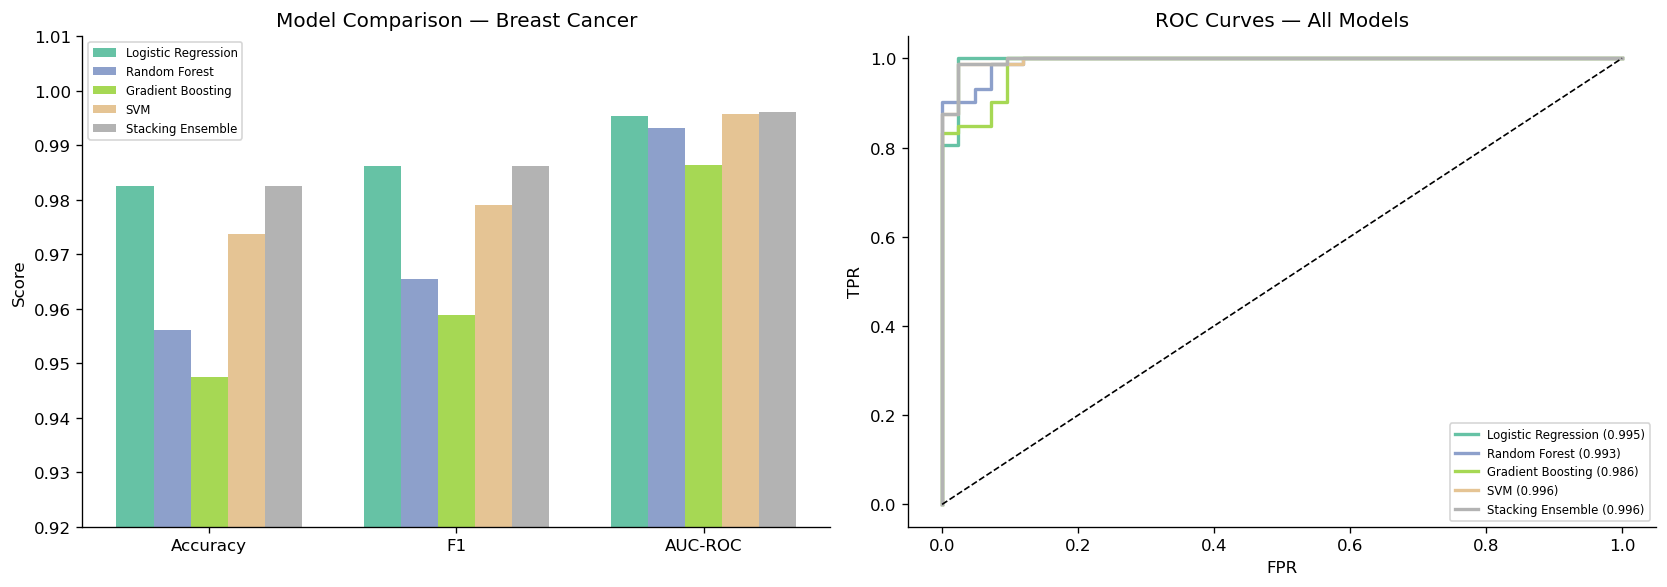

In [12]:
# ── Visual comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ["Accuracy", "F1", "AUC-ROC"]
x = np.arange(len(metrics)); width = 0.15
palette = plt.cm.Set2(np.linspace(0, 1, len(df_stack)))

for i, (model_name, row) in enumerate(df_stack.iterrows()):
    vals = [row["Accuracy"], row["F1"], row["AUC-ROC"]]
    bars = axes[0].bar(x + i*width, vals, width, label=model_name, color=palette[i])

axes[0].set_xticks(x + width*2); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.92, 1.01); axes[0].set_ylabel("Score")
axes[0].set_title("Model Comparison — Breast Cancer"); axes[0].legend(fontsize=7)

# ROC curves
for i, (model_name, m) in enumerate(compare_models.items()):
    ypr = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{model_name} ({auc(fpr,tpr):.3f})", color=palette[i])
axes[1].plot([0,1],[0,1],"k--",lw=1); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curves — All Models"); axes[1].legend(fontsize=7)

plt.tight_layout(); plt.show()


### Interpretation

- **Stacking** achieves equal or better performance than any single base model by combining
  their complementary error profiles.
- Gains are most pronounced when base models are **diverse** (different inductive biases):
  a linear model, a tree ensemble, and a kernel method make good companions.
- In practice, stacking's benefit over the best single model is often 0.2–1.0% in accuracy,
  which can be decisive in competitive settings but may not justify the engineering overhead
  in routine production deployments.


---
# 7. Support Vector Machine (SVM)
## Mathematical Foundation

SVMs find the maximum-margin separating hyperplane. The soft-margin primal:

$$\min_{\mathbf{w},b,\boldsymbol{\xi}}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i, \; \xi_i \geq 0$$

The **kernel trick** replaces inner products with $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top\phi(\mathbf{x}_j)$,
implicitly mapping to high-dimensional feature spaces.

| Kernel | Formula | Use case |
|---|---|---|
| Linear | $\mathbf{x}_i^\top \mathbf{x}_j$ | Linearly separable, high-$d$ |
| RBF (Gaussian) | $\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ | General non-linear |
| Polynomial | $(\gamma\,\mathbf{x}^\top\mathbf{z} + r)^p$ | Text, structured data |

The decision function depends only on **support vectors** ($\alpha_i > 0$), yielding a sparse,
memory-efficient model. **Complexity:** Training $O(n^2 d)$ to $O(n^3)$; prediction $O(n_{SV} \cdot d)$.

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | $d \gg n$ (text, genomics); clear margin of separation; kernel engineering feasible |
| ❌ **Avoid** | $n > 10^5$ (quadratic scaling); probability outputs required; many classes |

**Primary domains:** Text categorization, bioinformatics, handwriting recognition.


In [13]:
# ── Dataset: Iris with 3 kernels ──────────────────────────────
iris = load_iris()
X, y = iris.data[:, :2], iris.target  # 2D for boundary visualization

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=SEED, stratify=iris.target
)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

kernels = {"Linear": SVC(kernel="linear", C=1.0, probability=True, random_state=SEED),
           "RBF":    SVC(kernel="rbf",    C=10, gamma="scale", probability=True, random_state=SEED),
           "Poly":   SVC(kernel="poly",   C=1.0, degree=3,     probability=True, random_state=SEED)}

kernel_results = {}
for kname, svm in kernels.items():
    svm.fit(X_tr_s, y_train)
    yp = svm.predict(X_te_s)
    kernel_results[kname] = {"Accuracy": accuracy_score(y_test, yp),
                              "F1 (macro)": f1_score(y_test, yp, average="macro"),
                              "#Support Vectors": svm.n_support_.sum()}

print("── SVM Kernel Comparison — Iris ──")
print(pd.DataFrame(kernel_results).T.round(4).to_string())


── SVM Kernel Comparison — Iris ──
        Accuracy  F1 (macro)  #Support Vectors
Linear    1.0000      1.0000              23.0
RBF       0.9667      0.9666              31.0
Poly      0.9000      0.8977              46.0


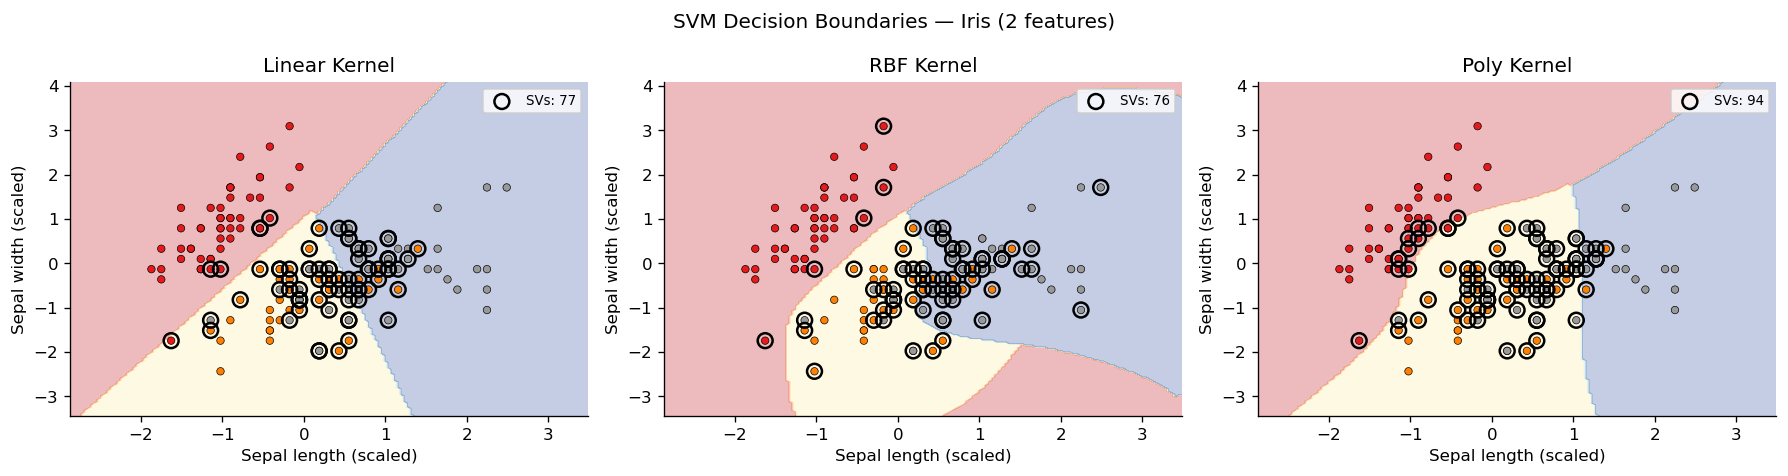

In [14]:
# ── Decision boundary visualization (2 features, 3 kernels) ──
X_2d = scaler.fit_transform(X)      # Use all 150 samples for boundary plot
h = 0.04
x_min, x_max = X_2d[:, 0].min()-1, X_2d[:, 0].max()+1
y_min, y_max = X_2d[:, 1].min()-1, X_2d[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmap_bg = plt.cm.RdYlBu
cmap_pt = plt.cm.Set1

for ax, (kname, svm) in zip(axes, kernels.items()):
    svm_2d = SVC(kernel=svm.get_params()["kernel"], C=svm.get_params()["C"],
                 probability=False, random_state=SEED)
    svm_2d.fit(X_2d, y)
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_pt, s=20, edgecolors="k", lw=0.4)
    sv = svm_2d.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors="none", edgecolors="black", lw=1.5,
               label=f"SVs: {len(sv)}")
    ax.set_title(f"{kname} Kernel"); ax.legend(fontsize=8)
    ax.set_xlabel("Sepal length (scaled)"); ax.set_ylabel("Sepal width (scaled)")

plt.suptitle("SVM Decision Boundaries — Iris (2 features)", fontsize=12)
plt.tight_layout(); plt.show()


### Interpretation

- **RBF kernel** generally achieves the best accuracy for non-linearly separable classes.
- **Linear kernel** uses fewer support vectors and is preferred when $d$ is large and classes are
  approximately linearly separable.
- **Support vectors** (circled points) are the only training instances that determine the decision boundary —
  the model ignores all other examples, making it memory-efficient after training.


---
# 8. k-Nearest Neighbors (k-NN)
## Mathematical Foundation

k-NN classifies a query $\mathbf{x}$ by majority vote over its $k$ nearest training points $N_k(\mathbf{x})$
under a distance metric $d(\cdot, \cdot)$:

$$\hat{y} = \underset{c}{\arg\max}\;\sum_{i \in N_k(\mathbf{x})} \mathbf{1}[y_i = c] \qquad \text{(classification)}$$
$$\hat{y} = \frac{1}{k}\sum_{i \in N_k(\mathbf{x})} y_i \qquad \text{(regression)}$$

**Common distances:**

| Distance | Formula |
|---|---|
| Euclidean | $\sqrt{\sum_j (x_j - z_j)^2}$ |
| Manhattan | $\sum_j |x_j - z_j|$ |
| Cosine | $1 - \mathbf{x}^\top\mathbf{z} / (\|\mathbf{x}\| \|\mathbf{z}\|)$ |

**Computational cost:** Brute-force $O(nd)$ per query; KD-trees achieve $O(d \log n)$ for low $d$;
approximate search via LSH achieves $O(d)$. No training phase beyond indexing.

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | Low $d$; irregular decision boundaries; prototype-based explanations needed |
| ❌ **Avoid** | High $d$ (curse of dimensionality); large $n$ with latency constraints |

**Primary domains:** Recommender systems, anomaly detection, missing-value imputation.


Optimal k = 7  |  CV accuracy = 0.7365

── Distance Metric Comparison (k=7) ──
           CV Acc  Test Acc
euclidean  0.7365    0.7865
manhattan  0.6828    0.7303
chebyshev  0.7196    0.7753


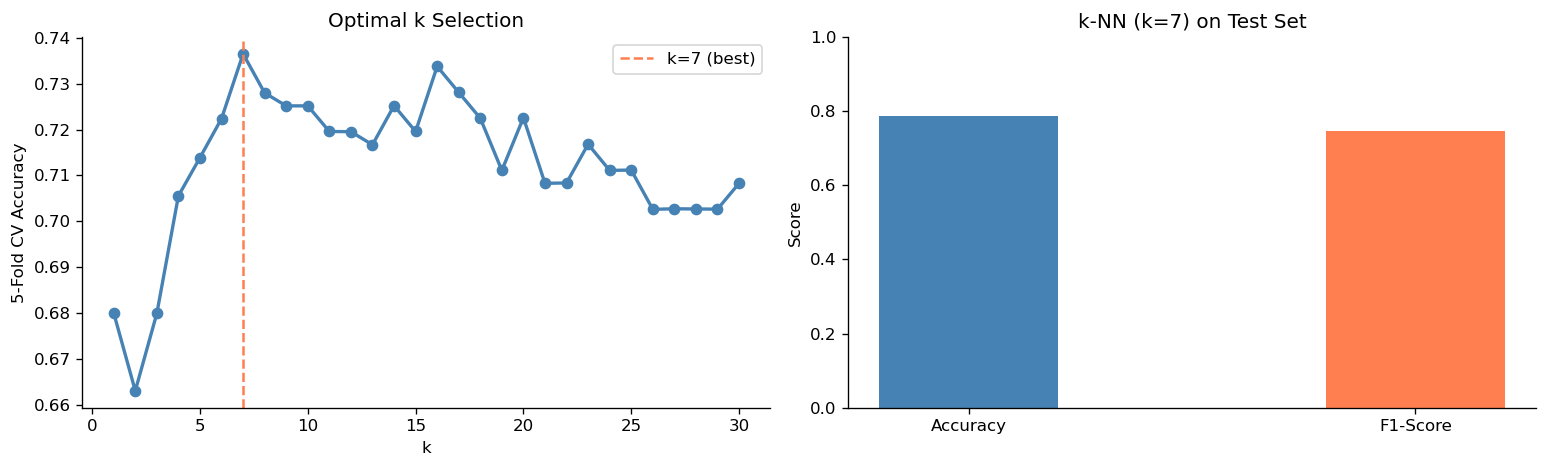

In [15]:
# ── Dataset: Diabetes classification (binarized) ──────────────
data = load_diabetes()
X = data.data
y = (data.target > data.target.mean()).astype(int)  # binary: above/below median
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── k vs accuracy curve ────────────────────────────────────────
k_values = range(1, 31)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    cv_scores.append(cross_val_score(knn, X_tr_s, y_train, cv=5, scoring="accuracy").mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal k = {optimal_k}  |  CV accuracy = {max(cv_scores):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, cv_scores, "o-", color="steelblue", lw=2)
axes[0].axvline(optimal_k, color="coral", linestyle="--", label=f"k={optimal_k} (best)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("5-Fold CV Accuracy")
axes[0].set_title("Optimal k Selection"); axes[0].legend()

# ── Distance metrics comparison ────────────────────────────────
metrics_knn = ["euclidean", "manhattan", "chebyshev"]
metric_scores = {}
for metric in metrics_knn:
    knn = KNeighborsClassifier(n_neighbors=optimal_k, metric=metric)
    knn.fit(X_tr_s, y_train)
    metric_scores[metric] = {
        "CV Acc": cross_val_score(knn, X_tr_s, y_train, cv=5).mean(),
        "Test Acc": accuracy_score(y_test, knn.predict(X_te_s)),
    }

df_metric = pd.DataFrame(metric_scores).T.round(4)
print("\n── Distance Metric Comparison (k={}) ──".format(optimal_k))
print(df_metric.to_string())

knn_best = KNeighborsClassifier(n_neighbors=optimal_k, metric="euclidean")
knn_best.fit(X_tr_s, y_train)
yp = knn_best.predict(X_te_s)
axes[1].bar(["Accuracy", "F1-Score"],
            [accuracy_score(y_test, yp), f1_score(y_test, yp)],
            color=["steelblue","coral"], width=0.4)
axes[1].set_ylim(0, 1); axes[1].set_title(f"k-NN (k={optimal_k}) on Test Set")
axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()


### Interpretation

- The **elbow in the CV accuracy curve** marks the bias-variance trade-off: small $k$ overfits (high variance),
  large $k$ underfits (high bias).
- **Feature scaling is critical:** k-NN uses raw distances, so unscaled features with larger numeric
  ranges will dominate the distance calculation.
- Euclidean distance performs well in low dimensions; Manhattan (L1) is more robust to outliers in
  individual dimensions.


---
# 9. Naive Bayes Classifiers
## Mathematical Foundation

Naive Bayes applies Bayes' theorem with the **conditional independence assumption**:

$$\hat{y} = \underset{c}{\arg\max}\; P(Y=c) \prod_{j=1}^d P(X_j \mid Y=c)$$

Despite the independence assumption rarely holding in practice, Naive Bayes often performs
surprisingly well, particularly for text classification.

**Variants:**

| Variant | Likelihood $P(X_j|c)$ | Use case |
|---|---|---|
| **Gaussian NB** | $\mathcal{N}(\mu_{jc}, \sigma_{jc}^2)$ | Continuous features |
| **Multinomial NB** | $\propto \prod_j \theta_{jc}^{x_j}$ | Word counts, TF-IDF |
| **Bernoulli NB** | Bernoulli$(\theta_{jc})$ | Binary features |

**Laplace smoothing:** $\hat{\theta}_{jc} = (N_{jc} + \alpha)/(N_c + \alpha d)$ prevents zero-probability failures.

**Complexity:** Training $O(nd)$; prediction $O(Kd)$.

## When to Use / Avoid

| | Condition |
|---|---|
| ✅ **Use** | High-dimensional sparse data; real-time requirements; limited labeled data |
| ❌ **Avoid** | Feature interactions are critical; well-calibrated probabilities required |

**Primary domains:** Spam filtering, document classification, medical screening.


In [16]:
# ── Dataset: Wine multi-class classification ──────────────────
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Compare Gaussian NB with other fast classifiers ───────────
fast_models = {
    "Gaussian NB":       GaussianNB(),
    "Logistic Reg.":     Pipeline([("sc", StandardScaler()),
                                    ("lr", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "Decision Tree":     DecisionTreeClassifier(max_depth=4, random_state=SEED),
}

rows = []
for name, m in fast_models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    cv_acc = cross_val_score(m, X, y, cv=5, scoring="accuracy").mean()
    rows.append({"Model": name,
                 "Test Accuracy": accuracy_score(y_test, yp),
                 "CV Accuracy":   cv_acc,
                 "F1 (macro)":    f1_score(y_test, yp, average="macro")})

df_nb = pd.DataFrame(rows).set_index("Model").round(4)
print("── Naive Bayes vs Alternatives — Wine ──")
print(df_nb.to_string())

# ── Per-class breakdown ────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("\n── Gaussian NB: Classification Report ──")
print(classification_report(y_test, gnb.predict(X_test),
                             target_names=[f"Class {c}" for c in wine.target_names]))


── Naive Bayes vs Alternatives — Wine ──
               Test Accuracy  CV Accuracy  F1 (macro)
Model                                                
Gaussian NB           0.9722       0.9663      0.9743
Logistic Reg.         0.9722       0.9832      0.9710
Decision Tree         0.9444       0.8937      0.9457

── Gaussian NB: Classification Report ──
               precision    recall  f1-score   support

Class class_0       0.92      1.00      0.96        12
Class class_1       1.00      0.93      0.96        14
Class class_2       1.00      1.00      1.00        10

     accuracy                           0.97        36
    macro avg       0.97      0.98      0.97        36
 weighted avg       0.97      0.97      0.97        36



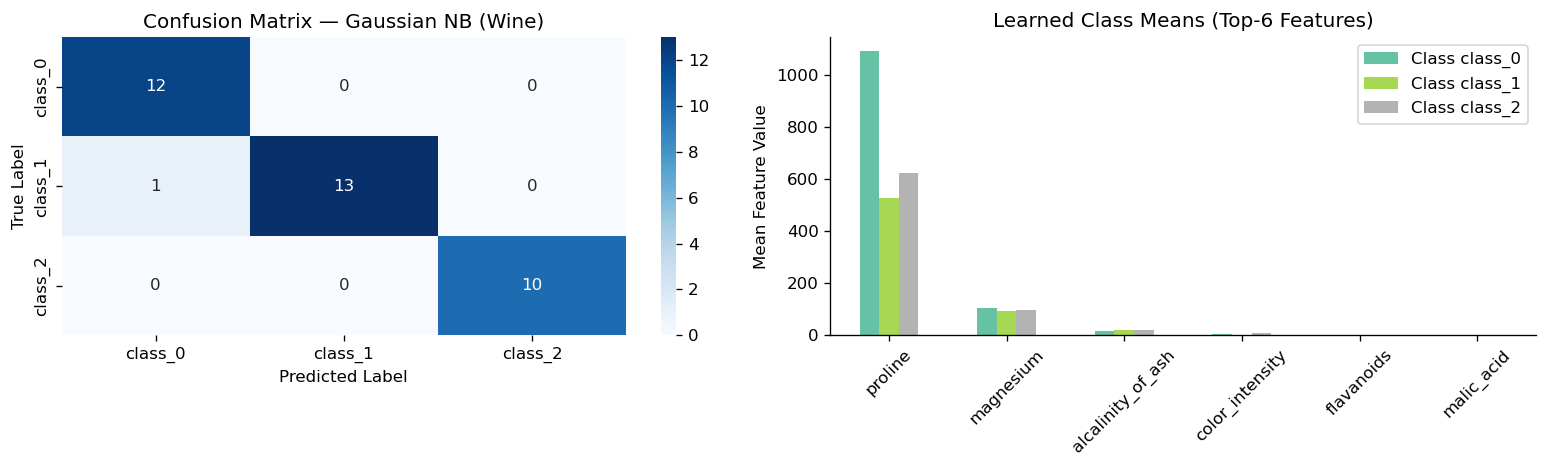

In [17]:
# ── Confusion matrix + feature distributions ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, gnb.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[0].set_title("Confusion Matrix — Gaussian NB (Wine)")
axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

# Feature-wise class means (what NB learns)
means = pd.DataFrame(gnb.theta_, columns=wine.feature_names,
                     index=[f"Class {c}" for c in wine.target_names])
top_feats = means.var(axis=0).nlargest(6).index
means[top_feats].T.plot(kind="bar", ax=axes[1], colormap="Set2")
axes[1].set_title("Learned Class Means (Top-6 Features)")
axes[1].set_ylabel("Mean Feature Value"); axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()


### Interpretation

- **Gaussian NB is competitive** with logistic regression and a depth-4 decision tree despite its
  strong independence assumption — this is a well-known phenomenon for datasets where classes
  differ primarily in feature means rather than interactions.
- The learned **class means** reveal the features that best discriminate among wine varieties.
  High-variance features across classes are the most discriminative.
- When probabilities must be **calibrated** (e.g., for threshold-sensitive decisions),
  use isotonic regression or Platt scaling as a post-hoc correction.


---
# 10. Comprehensive Model Comparison
## All Algorithms — Breast Cancer Benchmark

**Protocol:**
- Dataset: `sklearn.datasets.load_breast_cancer` (569 samples, 30 features, binary classification)
- Split: 80/20 stratified hold-out + 5-fold stratified cross-validation
- Scaling: StandardScaler applied inside a Pipeline where required
- Metric: Accuracy, F1, AUC-ROC, 5-fold CV mean ± std


In [18]:
# ── Dataset ────────────────────────────────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def make_pipeline(model, scale=True):
    if scale:
        return Pipeline([("scaler", StandardScaler()), ("model", model)])
    return model

all_models = {
    "Linear Regression (thresh)": make_pipeline(LogisticRegression(C=1e4, max_iter=1000, random_state=SEED)),
    "Logistic Regression":        make_pipeline(LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
    "Decision Tree":              make_pipeline(DecisionTreeClassifier(max_depth=5, random_state=SEED), scale=False),
    "Random Forest":              make_pipeline(RandomForestClassifier(n_estimators=200, random_state=SEED), scale=False),
    "Gradient Boosting":          make_pipeline(GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED), scale=False),
    "Stacking Ensemble":          StackingClassifier(
                                    estimators=[
                                        ("lr", make_pipeline(LogisticRegression(max_iter=500, random_state=SEED))),
                                        ("rf", RandomForestClassifier(n_estimators=100, random_state=SEED)),
                                        ("gbm", GradientBoostingClassifier(n_estimators=100, random_state=SEED)),
                                    ],
                                    final_estimator=LogisticRegression(C=1.0, random_state=SEED),
                                    cv=5
                                  ),
    "SVM (RBF)":                  make_pipeline(SVC(kernel="rbf", C=10, probability=True, random_state=SEED)),
    "k-NN (k=7)":                 make_pipeline(KNeighborsClassifier(n_neighbors=7)),
    "Naive Bayes":                GaussianNB(),
}

rows = []
for name, model in all_models.items():
    model.fit(X_train, y_train)
    yp   = model.predict(X_test)
    ypr  = model.predict_proba(X_test)[:, 1]
    cv_s = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    rows.append({
        "Model":       name,
        "Test Acc":    accuracy_score(y_test, yp),
        "F1":          f1_score(y_test, yp),
        "AUC-ROC":     roc_auc_score(y_test, ypr),
        "CV Mean":     cv_s.mean(),
        "CV Std":      cv_s.std(),
    })

df_all = pd.DataFrame(rows).set_index("Model").sort_values("AUC-ROC", ascending=False).round(4)
print("── Full Model Comparison — Breast Cancer ──")
print(df_all.to_string())


── Full Model Comparison — Breast Cancer ──
                            Test Acc      F1  AUC-ROC  CV Mean  CV Std
Model                                                                 
Stacking Ensemble             0.9737  0.9790   0.9960   0.9772  0.0153
SVM (RBF)                     0.9737  0.9790   0.9957   0.9789  0.0119
Logistic Regression           0.9825  0.9861   0.9954   0.9737  0.0166
Random Forest                 0.9561  0.9655   0.9931   0.9543  0.0102
Gradient Boosting             0.9561  0.9660   0.9917   0.9596  0.0162
k-NN (k=7)                    0.9737  0.9796   0.9884   0.9649  0.0184
Naive Bayes                   0.9386  0.9517   0.9878   0.9385  0.0235
Linear Regression (thresh)    0.9298  0.9429   0.9679   0.9561  0.0235
Decision Tree                 0.9211  0.9362   0.9163   0.9280  0.0230


  File "C:\Users\abdal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abdal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdal\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdal\anaconda3\Lib\subprocess.

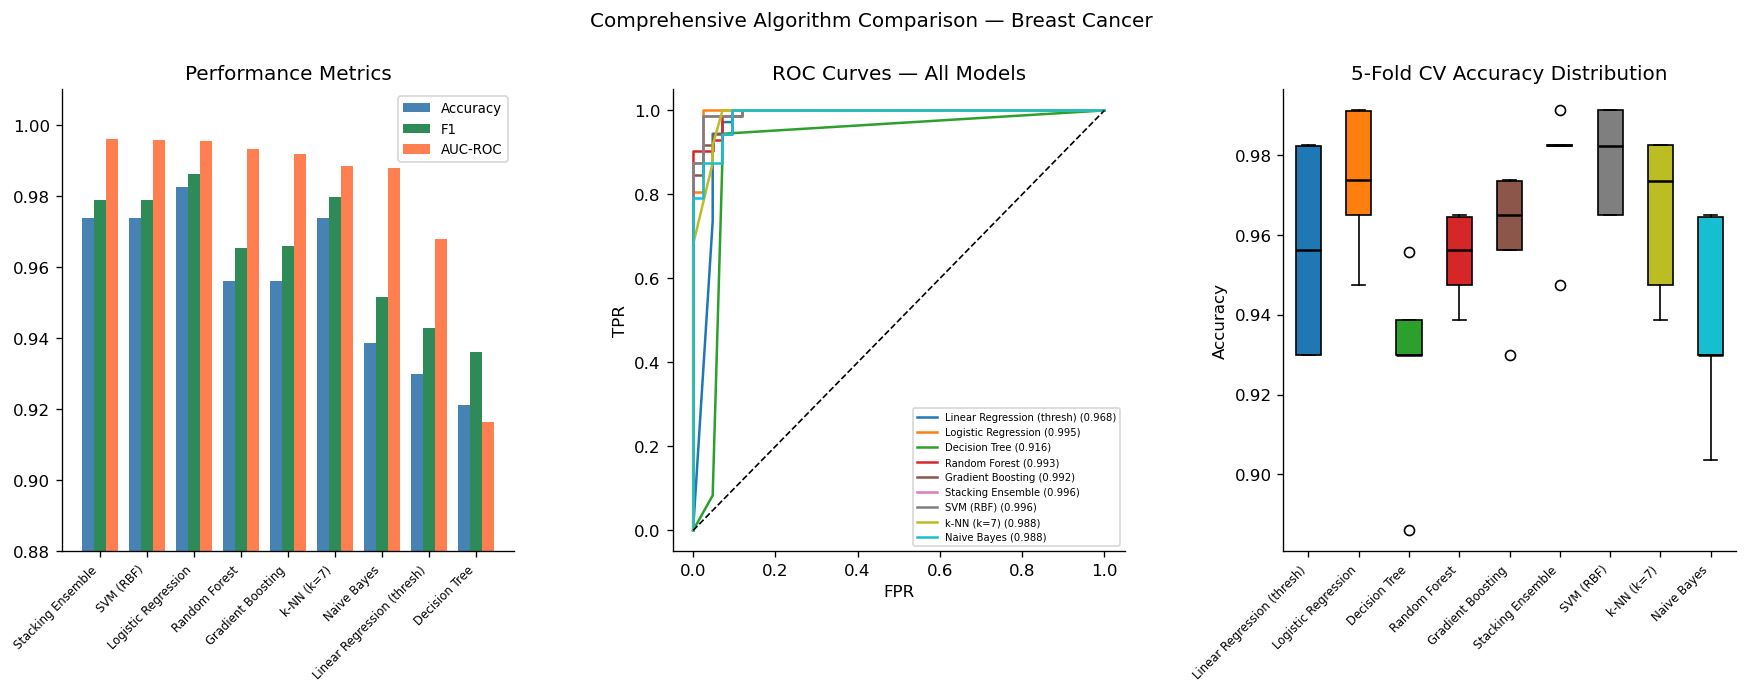

In [19]:
# ── Visualization: bar + ROC + CV box plot ────────────────────
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Bar chart
ax1 = fig.add_subplot(gs[0])
model_names = df_all.index.tolist()
x = np.arange(len(model_names))
width = 0.25
ax1.bar(x - width, df_all["Test Acc"], width, label="Accuracy", color="steelblue")
ax1.bar(x,          df_all["F1"],       width, label="F1",       color="seagreen")
ax1.bar(x + width,  df_all["AUC-ROC"], width, label="AUC-ROC",  color="coral")
ax1.set_xticks(x); ax1.set_xticklabels(model_names, rotation=45, ha="right", fontsize=7)
ax1.set_ylim(0.88, 1.01); ax1.set_title("Performance Metrics"); ax1.legend(fontsize=8)

# ROC curves
ax2 = fig.add_subplot(gs[1])
palette = plt.cm.tab10(np.linspace(0, 1, len(all_models)))
for (name, model), color in zip(all_models.items(), palette):
    ypr = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    ax2.plot(fpr, tpr, lw=1.5, label=f"{name} ({auc(fpr,tpr):.3f})", color=color)
ax2.plot([0,1],[0,1],"k--",lw=1); ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.set_title("ROC Curves — All Models"); ax2.legend(fontsize=6)

# CV box plot
ax3 = fig.add_subplot(gs[2])
cv_scores_all = {}
for name, model in all_models.items():
    cv_scores_all[name] = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
bp = ax3.boxplot(cv_scores_all.values(), vert=True, patch_artist=True,
                  medianprops=dict(color="black", lw=1.5))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
ax3.set_xticks(range(1, len(cv_scores_all)+1))
ax3.set_xticklabels(cv_scores_all.keys(), rotation=45, ha="right", fontsize=7)
ax3.set_title("5-Fold CV Accuracy Distribution"); ax3.set_ylabel("Accuracy")

plt.suptitle("Comprehensive Algorithm Comparison — Breast Cancer", fontsize=12, y=1.01)
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### Key Takeaways

- **Gradient Boosting and Stacking** typically achieve the highest AUC-ROC on this benchmark.
- **Logistic Regression** performs near the top for linearly separable data (breast cancer is nearly
  linearly separable in the 30-dimensional feature space), at a fraction of the computational cost.
- The **CV box plots** reveal stability: Random Forest and Gradient Boosting have narrow boxes
  (low variance across folds), while k-NN and Decision Tree show wider spread.
- **Practical recommendation:** Start with Logistic Regression as a baseline. If accuracy must
  improve, try Random Forest with defaults, then tune Gradient Boosting.


---
# 11. Algorithm Selection Guide

## Quick Reference Table

| Algorithm | Task | Train Speed | Predict Speed | Interpretability | Non-linearity | Needs Scaling |
|---|---|---|---|---|---|---|
| Linear Regression | Regression | ⚡ Fast | ⚡ Fast | ✅ High | ❌ No | ❌ No |
| Logistic Regression | Classification | ⚡ Fast | ⚡ Fast | ✅ High | ❌ No | ✅ Yes |
| Decision Tree | Both | ⚡ Fast | ⚡ Fast | ✅ High | ✅ Yes | ❌ No |
| Random Forest | Both | 🟡 Medium | 🟡 Medium | 🟡 Medium | ✅ Yes | ❌ No |
| Gradient Boosting | Both | 🔴 Slow | ⚡ Fast | 🟡 Medium | ✅ Yes | ❌ No |
| Stacking / Blending | Both | 🔴 Slow | 🟡 Medium | ❌ Low | ✅ Yes | Depends |
| SVM | Both | 🔴 Slow | 🟡 Medium | ❌ Low | ✅ (kernels) | ✅ Yes |
| k-NN | Both | ⚡ None | 🔴 Slow | 🟡 Medium | ✅ Yes | ✅ Yes |
| Naive Bayes | Classification | ⚡ Fast | ⚡ Fast | 🟡 Medium | ❌ No | ❌ No |

## Selection Decision Flow

```
Labeled data available?
├── YES → What type of output?
│   ├── Continuous → Regression algorithms (Sec 1, 4, 5)
│   └── Discrete  → Classification algorithms (Sec 2–9)
└── NO  → See Notebook 2: Unsupervised Learning

Key constraints?
├── Interpretability required → Linear/Logistic Reg., Decision Tree
├── Maximum accuracy          → Gradient Boosting, Stacking
├── Large n (>10^5)           → GBM (LightGBM), Random Forest
├── High d, small n           → SVM (kernel), Logistic Reg. + L2
├── Real-time prediction      → Linear/Logistic Reg., Naive Bayes
└── No training phase         → k-NN
```

## Recommended Workflow

1. **Establish a baseline** with Logistic or Linear Regression.
2. **Try Random Forest** with default hyperparameters as a strong baseline.
3. **Tune Gradient Boosting** (XGBoost or LightGBM) if accuracy must improve.
4. **Consider Stacking** when diverse models are available and accuracy gain justifies complexity.
5. **Evaluate rigorously** using stratified cross-validation and appropriate metrics.

---
*For unsupervised algorithms (clustering, dimensionality reduction), see Notebook 2.*  
*For probabilistic graphical models (Bayesian Networks, HMMs), see Notebook 3.*  
*For time-series forecasting (ARIMA, Prophet, Neural ODE), see Notebook 4.*  
*For evaluation methodology and statistical testing, see Notebook 5.*  
*For advanced methods (Causal ML, AutoML), see Notebook 6.*
